In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
%matplotlib inline

In [2]:
data = pd.read_excel("working_data.xlsx")
data

,Date,Personal number,Gender,Age,Amlodipine 5mg,Amlodipine 10mg,Lisinopril 5mg,Lisinopril 10mg,Furosemide 20mg,Furosemide 40mg,...,Nebivolol 5mg,Nebivolol 10mg,Avsar 10/160mg,Carvals H 160/25mg,Metoprolol 50mg,Exforge hct,Doxazosin 2mg,Doxazosin 4mg,Coversyl 10mg,Co-micardis 12.5/80
0,2024-02-01,A1488,Female,63,NaN,1.0,NaN,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-02-01,4684,Male,68,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-02-01,5737,Female,78,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024-02-01,A0457,Male,71,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2024-02-01,4991,Male,52,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3993,2024-09-19,7439,Male,59,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3994,2024-09-19,9832,Male,NaN,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3995,2024-09-19,88362,Male,51,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3996,2024-09-19,7131,Male,70,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
data.dtypes

Date                   datetime64[ns]
Personal number                object
Gender                         object
Age                            object
Amlodipine 5mg                float64
                            ...      
Exforge hct                   float64
Doxazosin 2mg                 float64
Doxazosin 4mg                 float64
Coversyl 10mg                 float64
Co-micardis 12.5/80           float64
Length: 61, dtype: object

In [4]:
data.Age.unique()

array([63, 68, 78, 71, 52, 58, 57, 72, 64, 73, 65, 67, 61, 69, 80, 74, 62,
       66, 54, 55, 28, 59, 70, 53, 50, 76, 35, nan, 40, 56, 79, 77, 45,
       42, 75, 46, 60, 83, 51, 36, 43, 34, 48, 88, 47, 85, 38, 26, 41, 82,
       44, 81, 37, 89, 49, 29, 32, 22, 84, 30, 18, 90, 27, 39, 31, 91, 87,
       33, 6, 21, 24, 15, 86, '\n', 92], dtype=object)

In [5]:
data['Age'].replace({'\n':np.nan})
data['Age'].replace({6:60}, inplace = True)
data['Age'] = pd.to_numeric(data['Age'], errors='coerce').astype('Int64')

C:\Users\USER\AppData\Local\Temp\ipykernel_21804\960462586.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Age'].replace({'\n':np.nan})
C:\Users\USER\AppData\Local\Temp\ipykernel_21804\960462586.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].replace({6:60}, inplace = True)

In [6]:
data['Age'].unique()

<IntegerArray>
[  63,   68,   78,   71,   52,   58,   57,   72,   64,   73,   65,   67,   61,
   69,   80,   74,   62,   66,   54,   55,   28,   59,   70,   53,   50,   76,
   35, <NA>,   40,   56,   79,   77,   45,   42,   75,   46,   60,   83,   51,
   36,   43,   34,   48,   88,   47,   85,   38,   26,   41,   82,   44,   81,
   37,   89,   49,   29,   32,   22,   84,   30,   18,   90,   27,   39,   31,
   91,   87,   33,   21,   24,   15,   86,   92]
Length: 73, dtype: Int64

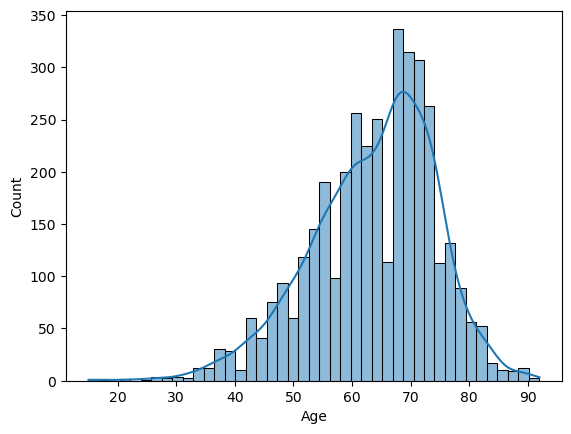

In [7]:
#checking for normality to fill up the Nan in the age column with either mean or median
import seaborn as sns
from scipy import stats

# Histogram and KDE
sns.histplot(data['Age'].dropna(), kde=True)
plt.show()

In [8]:
# Shapiro-Wilk test
stat, p = stats.shapiro(data['Age'].dropna())
print("Shapiro-Wilk Test p-value:", p)


Shapiro-Wilk Test p-value: 1.0217410734489282e-22


The distribution is left skewed and p in shapiro wilk test is less than 0.05, hence the data is not normally distributed.

In [9]:
if p > 0.05:  # roughly normal distribution
    fill_value = data['Age'].mean()
    print("Using mean:", fill_value)
else:  # skewed distribution
    fill_value = data['Age'].median()
    print("Using median:", fill_value)

# Fill NaN
data['Age'] = data['Age'].fillna(fill_value).astype(int)

Using median: 65.0


In [10]:
data.describe()

,Date,Age,Amlodipine 5mg,Amlodipine 10mg,Lisinopril 5mg,Lisinopril 10mg,Furosemide 20mg,Furosemide 40mg,Hydrochlorothiazide 12.5mg,Hydrochlorothiazide 25mg,...,Nebivolol 5mg,Nebivolol 10mg,Avsar 10/160mg,Carvals H 160/25mg,Metoprolol 50mg,Exforge hct,Doxazosin 2mg,Doxazosin 4mg,Coversyl 10mg,Co-micardis 12.5/80
count,3998,3998.000000,486.000000,2369.000000,236.000000,790.000000,34.000000,36.000000,35.000000,71.000000,...,4.000,0.0,27.000000,0.0,4.0,12.000000,1.0,18.000000,1.0,3.0
mean,2024-05-30 17:28:29.054527232,63.758629,0.993827,0.975095,1.002119,0.983544,1.132353,0.958333,0.885714,0.718310,...,0.625,NaN,1.074074,NaN,1.0,1.083333,1.0,1.055556,1.0,1.0
min,2024-02-01 00:00:00,15.000000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,...,0.500,NaN,1.000000,NaN,1.0,1.000000,1.0,0.500000,1.0,1.0
25%,2024-04-02 00:00:00,58.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.500000,...,0.500,NaN,1.000000,NaN,1.0,1.000000,1.0,1.000000,1.0,1.0
50%,2024-05-29 00:00:00,65.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.500000,...,0.500,NaN,1.000000,NaN,1.0,1.000000,1.0,1.000000,1.0,1.0
75%,2024-07-26 00:00:00,71.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.625,NaN,1.000000,NaN,1.0,1.000000,1.0,1.000000,1.0,1.0
max,2025-05-30 00:00:00,92.000000,2.000000,2.000000,2.000000,2.000000,4.000000,2.000000,1.000000,1.000000,...,1.000,NaN,2.000000,NaN,1.0,2.000000,1.0,2.000000,1.0,1.0
std,NaN,10.294003,0.136083,0.125052,0.192950,0.158358,0.606890,0.324588,0.213021,0.249748,...,0.250,NaN,0.266880,NaN,0.0,0.288675,NaN,0.379198,NaN,0.0


In [11]:
#value counts of the gender parameter
data['Gender'].value_counts()

Gender
Male      2196
Female    1802
Name: count, dtype: int64

In [12]:
data.groupby('Gender')['Age'].mean()

Gender
Female    60.972253
Male      66.045082
Name: Age, dtype: float64

In [13]:
#Getting female and male age list
female_ages_list = data.loc[data['Gender'] == 'Female', 'Age'].tolist()
male_ages_list = data.loc[data['Gender'] == 'Male', 'Age'].tolist()

In [14]:
# 1. Independent samples t-test to compare the female ages and the male ages
import scipy.stats as stats
t_stat, p_value = stats.ttest_ind(female_ages_list, male_ages_list)
print(f"Independent t-test: t={t_stat:.4f}, p={p_value:.4f}")

Independent t-test: t=-15.9901, p=0.0000


Feature Enginereering
- Extract month name from the date column

- Extract day of week from the date column

In [15]:
# Extract month name 
data['Month'] = data['Date'].dt.month_name()

# Extract day of week 
data['DayOfWeek'] = data['Date'].dt.day_name()

In [16]:
#checking
data

,Date,Personal number,Gender,Age,Amlodipine 5mg,Amlodipine 10mg,Lisinopril 5mg,Lisinopril 10mg,Furosemide 20mg,Furosemide 40mg,...,Avsar 10/160mg,Carvals H 160/25mg,Metoprolol 50mg,Exforge hct,Doxazosin 2mg,Doxazosin 4mg,Coversyl 10mg,Co-micardis 12.5/80,Month,DayOfWeek
0,2024-02-01,A1488,Female,63,NaN,1.0,NaN,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,February,Thursday
1,2024-02-01,4684,Male,68,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,February,Thursday
2,2024-02-01,5737,Female,78,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,February,Thursday
3,2024-02-01,A0457,Male,71,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,February,Thursday
4,2024-02-01,4991,Male,52,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,February,Thursday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3993,2024-09-19,7439,Male,59,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,September,Thursday
3994,2024-09-19,9832,Male,65,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,September,Thursday
3995,2024-09-19,88362,Male,51,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,September,Thursday
3996,2024-09-19,7131,Male,70,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,September,Thursday


### Objective one
A Count how many times each drug was dispensed irrespective of supply duration.
That means just count non-blank entries per drug.

In [17]:
# Identify drug columns
drug_columns = [col for col in data.columns if col not in ['Date','Personal number','Gender', 'Age', 'DayOfWeek', 'Month']]

# Count how many times each drug was dispensed (non-NA entries)
dispense_counts = data[drug_columns].notna().sum().sort_values(ascending=False)

# Display top 10
print("Top 20 dispensed drugs:")
print(dispense_counts.head(20))

Top 20 dispensed drugs:
Amlodipine 10mg              2369
Lisinopril 10mg               790
Losartan 50mg                 642
Indapamide 1.5mg              520
Amlodipine 5mg                486
Bendroflumethiazide 2.5mg     474
Bisoprolol 2.5mg              372
Losartan 100mg                282
Lisinopril 5mg                236
Normoretic                    233
Telmisartan 80mg              129
Spirinolactone                116
Hydrochlorothiazide 25mg       71
Valsartan 160mg                68
Nifedipine XL 30mg             63
Nifedipine 20mg                58
Methyldopa 250mg               55
Candesartan 16mg               54
Aprovasc                       52
Co-diovan                      52
dtype: int64


In [18]:
#count how many times half, one, two and three packs of the medication were given


# Identify drug columns
drug_columns = [col for col in data.columns if col not in ['Date','Personal number','Gender', 'Age', 'DayOfWeek', 'Month']]

# Define pack sizes
pack_sizes = [0.5, 1.0, 2.0, 3.0, 4.0]

# Compute total dispense counts (non-null)
total_dispense = data[drug_columns].notna().sum().sort_values(ascending=False)

# Initialize DataFrame for detailed counts
dispense_counts = pd.DataFrame(index=drug_columns, columns=pack_sizes)

# Count for each drug and each pack size
for drug in drug_columns:
    for size in pack_sizes:
        dispense_counts.loc[drug, size] = (data[drug] == size).sum()

# Convert to numeric
dispense_counts = dispense_counts.astype(int)

# Add the total column (total dispenses per drug)
dispense_counts['Total'] = data[drug_columns].notna().sum()

# Now reorder rows to match the sorted order of total_dispense
dispense_counts = dispense_counts.loc[total_dispense.index]

# Display top 20 for example
(dispense_counts) 

,0.5,1.0,2.0,3.0,4.0,Total
Amlodipine 10mg,130,2233,6,0,0,2369
Lisinopril 10mg,44,737,9,0,0,790
Losartan 50mg,61,575,5,0,1,642
Indapamide 1.5mg,44,476,0,0,0,520
Amlodipine 5mg,16,465,5,0,0,486
Bendroflumethiazide 2.5mg,2,462,6,2,1,474
Bisoprolol 2.5mg,28,335,3,2,4,372
Losartan 100mg,0,282,0,0,0,282
Lisinopril 5mg,11,219,6,0,0,236
Normoretic,26,207,0,0,0,233


Questions- from the data- On the average- What percentage of the patient that visit the clinic per day collect a particular drug say amlodipine

And what is the probability that an anti-hypertensive patient in the clinic takes amlodipine

In [19]:
# 1. Average daily % collecting each drug

daily_percentages = {}
drug_columns = [col for col in data.columns if col not in ['Date','Personal number','Gender', 'Age', 'DayOfWeek', 'Month']]
for drug in drug_columns:
    daily_stats = data.groupby('Date').agg(
        total_patients=('Personal number', 'count'),
        drug_patients=(drug, lambda x: x.notna().sum())
    )
    daily_stats['pct'] = (daily_stats['drug_patients'] / daily_stats['total_patients']) * 100
    daily_percentages[drug] = daily_stats['pct'].mean()

avg_daily_pct_df = pd.DataFrame.from_dict(daily_percentages, orient='index', columns=['AvgDailyPct'])
avg_daily_pct_df = avg_daily_pct_df.sort_values(by='AvgDailyPct', ascending=False)

In [20]:
daily_stats

,total_patients,drug_patients,pct
Date,,,
2024-02-01,27,0,0.000000
2024-02-02,35,0,0.000000
2024-02-05,57,0,0.000000
2024-02-07,22,0,0.000000
2024-02-08,35,0,0.000000
...,...,...,...
2024-09-16,23,1,4.347826
2024-09-17,24,0,0.000000
2024-09-18,25,0,0.000000


In [21]:
avg_daily_pct_df

,AvgDailyPct
Amlodipine 10mg,59.391133
Lisinopril 10mg,20.229796
Losartan 50mg,15.976888
Indapamide 1.5mg,12.534982
Bendroflumethiazide 2.5mg,12.357110
Amlodipine 5mg,12.042729
Bisoprolol 2.5mg,9.651193
Losartan 100mg,7.205331
Lisinopril 5mg,6.370928
Normoretic,5.730941


In [22]:
# 2. Probability each antihypertensive patient takes each drug
# ----------------------------

probabilities = {}

# Identify patients with any antihypertensive
data['any_antihypertensive'] = data[drug_columns].notna().any(axis=1)
total_antihypertensive = data['any_antihypertensive'].sum()

for drug in drug_columns:
    drug_patients = data.loc[data['any_antihypertensive'], drug].notna().sum()
    probabilities[drug] = drug_patients / total_antihypertensive

prob_df = pd.DataFrame.from_dict(probabilities, orient='index', columns=['Probability'])
prob_df = prob_df.sort_values(by='Probability', ascending=False)

In [23]:
prob_df

,Probability
Amlodipine 10mg,0.592991
Lisinopril 10mg,0.197747
Losartan 50mg,0.160701
Indapamide 1.5mg,0.130163
Amlodipine 5mg,0.121652
Bendroflumethiazide 2.5mg,0.118648
Bisoprolol 2.5mg,0.093116
Losartan 100mg,0.070588
Lisinopril 5mg,0.059074
Normoretic,0.058323


In [24]:
# --- Combine both into one table ---
pct_prob = avg_daily_pct_df.join(prob_df)
pct_prob = pct_prob.sort_values(by='AvgDailyPct', ascending=False)
pct_prob

,AvgDailyPct,Probability
Amlodipine 10mg,59.391133,0.592991
Lisinopril 10mg,20.229796,0.197747
Losartan 50mg,15.976888,0.160701
Indapamide 1.5mg,12.534982,0.130163
Bendroflumethiazide 2.5mg,12.357110,0.118648
Amlodipine 5mg,12.042729,0.121652
Bisoprolol 2.5mg,9.651193,0.093116
Losartan 100mg,7.205331,0.070588
Lisinopril 5mg,6.370928,0.059074
Normoretic,5.730941,0.058323


### Day of the week and filled prescription

In [25]:
# Identify drug columns (exclude ID info)
drug_columns = [col for col in data.columns if col not in ['Date','Personal number','Gender', 'Age', 'DayOfWeek', 'Month']]

# A prescription is filled if at least one drug is dispensed
data['PrescriptionFilled'] = data[drug_columns].notna().any(axis=1)

# Group by day of week and count prescriptions
day_counts = data.groupby('DayOfWeek')['PrescriptionFilled'].sum().sort_values(ascending=False)

print(day_counts)

DayOfWeek
Monday       851
Tuesday      825
Thursday     823
Wednesday    759
Friday       740
Name: PrescriptionFilled, dtype: int64


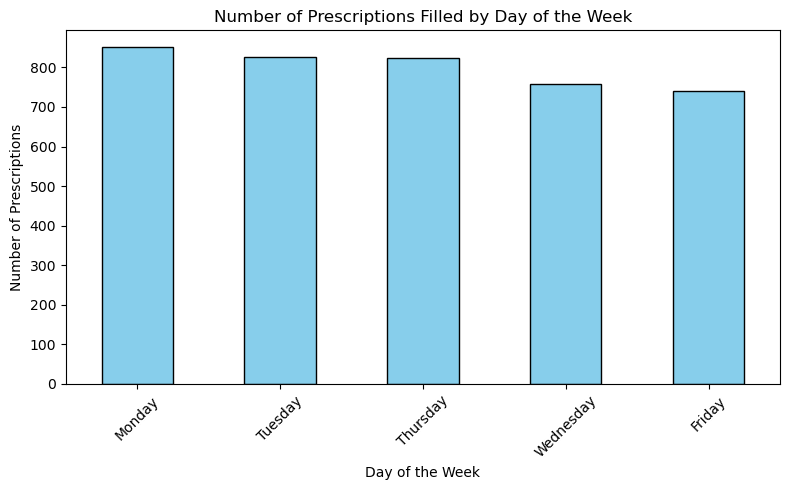

In [26]:
#plot
plt.figure(figsize=(8,5))
day_counts.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title("Number of Prescriptions Filled by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Number of Prescriptions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
data.columns

Index(['Date', 'Personal number', 'Gender', 'Age', 'Amlodipine 5mg',
       'Amlodipine 10mg', 'Lisinopril 5mg', 'Lisinopril 10mg',
       'Furosemide 20mg', 'Furosemide 40mg', 'Hydrochlorothiazide 12.5mg',
       'Hydrochlorothiazide 25mg', 'Normoretic', 'Torsemide 10mg',
       'Torsemide 20mg', 'Telmisartan 40mg', 'Telmisartan 80mg',
       'Nifedipine 20mg', 'Nifedipine XL 30mg', 'Labetalol hydrochloride',
       'Methyldopa 250mg', 'Methyldopa 500mg', 'Bendroflumethiazide 2.5mg',
       'Losartan 50mg', 'Losartan 100mg', 'Indapamide 1.5mg', 'Valsartan 80mg',
       'Valsartan 160mg', 'Bisoprolol 2.5mg', 'Bisoprolol 5mg',
       'Candesartan 8mg', 'Candesartan 16mg', 'Avantec 16/12.5',
       'Avantec 32/12.5', 'Twynsta', 'Aprovasc', 'Coveram(5mg/1.25mg/5mg)',
       'Coveram plus(10mg/2.5mg/10mg)', 'Coveram plus(5mg/2.5mg/5mg)',
       'Coveram 5mg/5mg', 'Coveram (10mg/10mg)', 'Captopril',
       'Carvedilol 3.125mg', 'Carvedilol 6.25mg', 'Carvedilol 12.5mg',
       'Co-diovan', '

## Month and filled prescription

In [28]:
drug_columns = [col for col in data.columns if col not in ['Date','Personal number','Gender', 'Age', 'DayOfWeek', 'Month', 'any_antihypertensive', 'PrescriptionFilled']]

# Group by month and count prescriptions
month_counts = data.groupby('Month')['PrescriptionFilled'].sum().sort_values(ascending=False)

print(month_counts)

Month
July         612
May          563
April        511
February     510
August       502
March        470
June         453
September    377
Name: PrescriptionFilled, dtype: int64


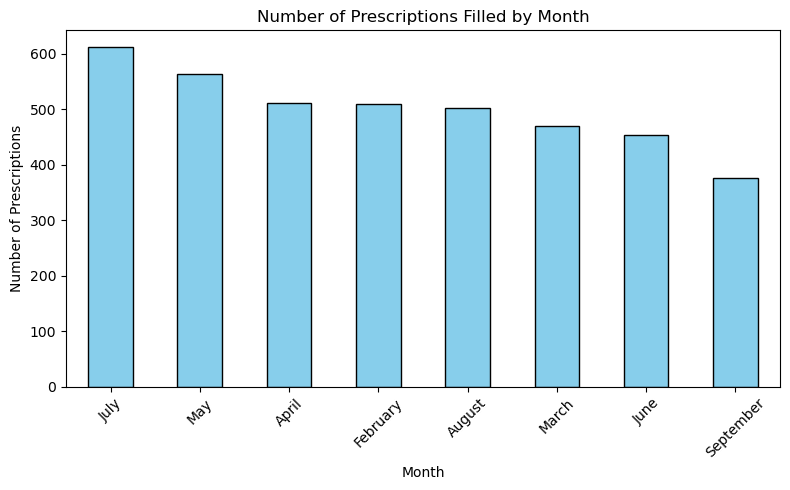

In [29]:
#plot bar

plt.figure(figsize=(8,5))
month_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Number of Prescriptions Filled by Month")
plt.xlabel("Month")
plt.ylabel("Number of Prescriptions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Detecting Early Refills

In [30]:
# Identify drug columns (exclude non-drug fields)
drug_columns = [col for col in data.columns 
                if col not in ['Date','Personal number','Gender', 'Age', 
                               'DayOfWeek', 'Month', 'any_antihypertensive', 'PrescriptionFilled']]

# Define mapping for 30-tablet packs
supply_map_30 = {0.5: 15, 1.0: 30, 2.0: 60, 3.0: 90, 4.0: 120}

# Define mapping for 28-tablet packs
supply_map_28 = {0.5: 14, 1.0: 28, 2.0: 56, 3.0: 84, 4.0: 112}

# Define mapping for methyldopa 250mg 
methyldopa250mg = {1:7, 2:15, 3:22, 4:30}

# List of drugs with 28 tablets per pack
drugs_28_pack = [
    'Lisinopril 5mg', 
    'Lisinopril 10mg', 
    'Bisoprolol 2.5mg',
    'Bisoprolol 5mg', 
    'Candesartan 8mg',
    'Candesartan 16mg',
    'Atenolol 50mg',
    'Atenolol 100mg',
    'Propanolol 40mg',
    'Propanolol 80mg',
    'Co-diovan',
    'Avsar 10/160mg',
    'Exforge hct',
    'Co-micardis 12.5/80',
    'Doxazosin 2mg',
    'Doxazosin 2mg',
    'Avantec 16/12.5',
    'Avantec 32/12.5',
    'Valsartan 80mg',
    'Valsartan 160mg',
    'Bendroflumethiazide 2.5mg',
    'Furosemide 20mg',
    'Furosemide 40mg',
    'Aprovasc'
]

# Apply correct mapping for each drug
for drug in drug_columns:
    if drug in drugs_28_pack:
        data[f'{drug}_days'] = data[drug].map(supply_map_28)
    elif drug == 'Methyldopa 250mg':
        data[f'{drug}_days'] = data[drug].map(methyldopa250mg)
    else:
        data[f'{drug}_days'] = data[drug].map(supply_map_30)

data


,Date,Personal number,Gender,Age,Amlodipine 5mg,Amlodipine 10mg,Lisinopril 5mg,Lisinopril 10mg,Furosemide 20mg,Furosemide 40mg,...,Nebivolol 5mg_days,Nebivolol 10mg_days,Avsar 10/160mg_days,Carvals H 160/25mg_days,Metoprolol 50mg_days,Exforge hct_days,Doxazosin 2mg_days,Doxazosin 4mg_days,Coversyl 10mg_days,Co-micardis 12.5/80_days
0,2024-02-01,A1488,Female,63,NaN,1.0,NaN,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-02-01,4684,Male,68,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-02-01,5737,Female,78,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024-02-01,A0457,Male,71,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2024-02-01,4991,Male,52,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3993,2024-09-19,7439,Male,59,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3994,2024-09-19,9832,Male,65,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3995,2024-09-19,88362,Male,51,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3996,2024-09-19,7131,Male,70,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
keep_cols = ['Date','Personal number','Gender'] +[f'{drug}_days' for drug in drug_columns]
data[keep_cols].head(20)

,Date,Personal number,Gender,Amlodipine 5mg_days,Amlodipine 10mg_days,Lisinopril 5mg_days,Lisinopril 10mg_days,Furosemide 20mg_days,Furosemide 40mg_days,Hydrochlorothiazide 12.5mg_days,...,Nebivolol 5mg_days,Nebivolol 10mg_days,Avsar 10/160mg_days,Carvals H 160/25mg_days,Metoprolol 50mg_days,Exforge hct_days,Doxazosin 2mg_days,Doxazosin 4mg_days,Coversyl 10mg_days,Co-micardis 12.5/80_days
0,2024-02-01,A1488,Female,NaN,30.0,NaN,28.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-02-01,4684,Male,NaN,30.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-02-01,5737,Female,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024-02-01,A0457,Male,NaN,30.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2024-02-01,4991,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2024-02-01,A1785,Male,NaN,30.0,NaN,28.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2024-02-01,6564,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2024-02-01,8633,Female,NaN,30.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2024-02-01,23452,Female,NaN,30.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2024-02-01,8944,Female,NaN,30.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
#adding a unique entry Id field
data['Entry_ID'] = range( 1, len(data) + 1)
data

,Date,Personal number,Gender,Age,Amlodipine 5mg,Amlodipine 10mg,Lisinopril 5mg,Lisinopril 10mg,Furosemide 20mg,Furosemide 40mg,...,Nebivolol 10mg_days,Avsar 10/160mg_days,Carvals H 160/25mg_days,Metoprolol 50mg_days,Exforge hct_days,Doxazosin 2mg_days,Doxazosin 4mg_days,Coversyl 10mg_days,Co-micardis 12.5/80_days,Entry_ID
0,2024-02-01,A1488,Female,63,NaN,1.0,NaN,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,2024-02-01,4684,Male,68,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
2,2024-02-01,5737,Female,78,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
3,2024-02-01,A0457,Male,71,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
4,2024-02-01,4991,Male,52,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3993,2024-09-19,7439,Male,59,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3994
3994,2024-09-19,9832,Male,65,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3995
3995,2024-09-19,88362,Male,51,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3996
3996,2024-09-19,7131,Male,70,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3997


In [33]:
# Sort by patient and date
data = data.sort_values(by=['Personal number', 'Gender', 'Date'])
data

,Date,Personal number,Gender,Age,Amlodipine 5mg,Amlodipine 10mg,Lisinopril 5mg,Lisinopril 10mg,Furosemide 20mg,Furosemide 40mg,...,Nebivolol 10mg_days,Avsar 10/160mg_days,Carvals H 160/25mg_days,Metoprolol 50mg_days,Exforge hct_days,Doxazosin 2mg_days,Doxazosin 4mg_days,Coversyl 10mg_days,Co-micardis 12.5/80_days,Entry_ID
1121,2024-04-08,286,Female,67,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1122
2450,2024-06-27,1221,Male,84,NaN,1.0,NaN,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2451
1152,2024-04-12,1406,Male,81,NaN,NaN,NaN,NaN,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1153
1553,2024-05-06,1406,Male,81,NaN,NaN,NaN,NaN,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1554
3898,2024-09-13,1425,Female,70,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3899
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1787,2024-05-17,PRIVATE,Male,72,NaN,1.0,NaN,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1788
1336,2024-04-23,Police,Male,45,NaN,1.0,NaN,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1337
1342,2024-04-23,SEAVIEW,Female,52,NaN,1.0,NaN,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1343
2256,2024-06-14,SEAVIEW,Male,50,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2257


In [34]:
def detect_early_refills(group, drug):
    group = group.copy()
    mask = group[f'{drug}_days'].notna()
    sub = group.loc[mask, ['Entry_ID', 'Date', f'{drug}_days']].copy()

    # Compute expected and next visit
    sub['Expected_Refill'] = sub['Date'] + pd.to_timedelta(sub[f'{drug}_days'], unit='D')
    sub['Next_Visit'] = sub['Date'].shift(-1)
    sub['Early_Refill'] = sub['Next_Visit'] < sub['Expected_Refill']

    # Compute number of days remaining
    sub['Days_Remaining'] = (sub['Expected_Refill'] - sub['Next_Visit']).dt.days

    # Only keep days remaining where early refill occurred
    sub.loc[~sub['Early_Refill'], 'Days_Remaining'] = None

    # Merge back
    group = group.merge(sub[['Entry_ID', 'Days_Remaining', 'Early_Refill']],
                        on='Entry_ID', how='left')
    group[f'{drug}_Early'] = group['Early_Refill']
    group[f'{drug}_Days_Remaining'] = group['Days_Remaining']
    group = group.drop(columns=['Early_Refill', 'Days_Remaining'])
    return group


In [36]:
data.columns

Index(['Date', 'Personal number', 'Gender', 'Age', 'Amlodipine 5mg',
       'Amlodipine 10mg', 'Lisinopril 5mg', 'Lisinopril 10mg',
       'Furosemide 20mg', 'Furosemide 40mg',
       ...
       'Nebivolol 10mg_days', 'Avsar 10/160mg_days', 'Carvals H 160/25mg_days',
       'Metoprolol 50mg_days', 'Exforge hct_days', 'Doxazosin 2mg_days',
       'Doxazosin 4mg_days', 'Coversyl 10mg_days', 'Co-micardis 12.5/80_days',
       'Entry_ID'],
      dtype='object', length=123)

In [37]:
#checking
df_check = data.groupby(['Personal number', 'Gender'], group_keys=False, observed=True).apply(
    detect_early_refills, drug='Amlodipine 10mg'
)


C:\Users\USER\AppData\Local\Temp\ipykernel_21804\1773069139.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_check = data.groupby(['Personal number', 'Gender'], group_keys=False, observed=True).apply(


In [38]:
df_check['Amlodipine 10mg_Early'].value_counts()

Amlodipine 10mg_Early
False    1913
True      456
Name: count, dtype: int64

In [39]:
# Apply for all drugs, grouped by patient
for drug in drug_columns:
    data = data.groupby(['Personal number','Gender'], group_keys=False, observed=True).apply(detect_early_refills, drug=drug)
    data[f'{drug}_Early'] = data[f'{drug}_Early'].fillna(False)

C:\Users\USER\AppData\Local\Temp\ipykernel_21804\518166357.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = data.groupby(['Personal number','Gender'], group_keys=False, observed=True).apply(detect_early_refills, drug=drug)
C:\Users\USER\AppData\Local\Temp\ipykernel_21804\518166357.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[f'{drug}_Early'] = data[f'{drug}_Early'].fillna(False)
C:\Users\USER\AppData\Local\Temp\ipykernel_21804\518166357.py:3: DeprecationWarni

In [40]:
data

,Date,Personal number,Gender,Age,Amlodipine 5mg,Amlodipine 10mg,Lisinopril 5mg,Lisinopril 10mg,Furosemide 20mg,Furosemide 40mg,...,Exforge hct_Early,Exforge hct_Days_Remaining,Doxazosin 2mg_Early,Doxazosin 2mg_Days_Remaining,Doxazosin 4mg_Early,Doxazosin 4mg_Days_Remaining,Coversyl 10mg_Early,Coversyl 10mg_Days_Remaining,Co-micardis 12.5/80_Early,Co-micardis 12.5/80_Days_Remaining
0,2024-04-08,286,Female,67,NaN,1.0,NaN,NaN,NaN,NaN,...,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN
0,2024-06-27,1221,Male,84,NaN,1.0,NaN,1.0,NaN,NaN,...,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN
0,2024-04-12,1406,Male,81,NaN,NaN,NaN,NaN,1.0,NaN,...,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN
1,2024-05-06,1406,Male,81,NaN,NaN,NaN,NaN,1.0,NaN,...,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN
0,2024-09-13,1425,Female,70,NaN,NaN,NaN,NaN,NaN,NaN,...,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1,2024-05-17,PRIVATE,Male,72,NaN,1.0,NaN,1.0,NaN,NaN,...,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN
0,2024-04-23,Police,Male,45,NaN,1.0,NaN,1.0,NaN,NaN,...,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN
0,2024-04-23,SEAVIEW,Female,52,NaN,1.0,NaN,1.0,NaN,NaN,...,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN
0,2024-06-14,SEAVIEW,Male,50,NaN,1.0,NaN,NaN,NaN,NaN,...,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN


In [41]:
keep_cols = ['Date','Personal number','Gender', 'Entry_ID'] +[f'{drug}_Early' for drug in drug_columns]
data[keep_cols]

,Date,Personal number,Gender,Entry_ID,Amlodipine 5mg_Early,Amlodipine 10mg_Early,Lisinopril 5mg_Early,Lisinopril 10mg_Early,Furosemide 20mg_Early,Furosemide 40mg_Early,...,Nebivolol 5mg_Early,Nebivolol 10mg_Early,Avsar 10/160mg_Early,Carvals H 160/25mg_Early,Metoprolol 50mg_Early,Exforge hct_Early,Doxazosin 2mg_Early,Doxazosin 4mg_Early,Coversyl 10mg_Early,Co-micardis 12.5/80_Early
0,2024-04-08,286,Female,1122,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
0,2024-06-27,1221,Male,2451,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
0,2024-04-12,1406,Male,1153,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,2024-05-06,1406,Male,1554,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
0,2024-09-13,1425,Female,3899,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1,2024-05-17,PRIVATE,Male,1788,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
0,2024-04-23,Police,Male,1337,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
0,2024-04-23,SEAVIEW,Female,1343,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
0,2024-06-14,SEAVIEW,Male,2257,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [42]:
#assigning to a different dataframe
early_df =  data[keep_cols]

In [43]:
early_df.columns

Index(['Date', 'Personal number', 'Gender', 'Entry_ID', 'Amlodipine 5mg_Early',
       'Amlodipine 10mg_Early', 'Lisinopril 5mg_Early',
       'Lisinopril 10mg_Early', 'Furosemide 20mg_Early',
       'Furosemide 40mg_Early', 'Hydrochlorothiazide 12.5mg_Early',
       'Hydrochlorothiazide 25mg_Early', 'Normoretic_Early',
       'Torsemide 10mg_Early', 'Torsemide 20mg_Early',
       'Telmisartan 40mg_Early', 'Telmisartan 80mg_Early',
       'Nifedipine 20mg_Early', 'Nifedipine XL 30mg_Early',
       'Labetalol hydrochloride_Early', 'Methyldopa 250mg_Early',
       'Methyldopa 500mg_Early', 'Bendroflumethiazide 2.5mg_Early',
       'Losartan 50mg_Early', 'Losartan 100mg_Early', 'Indapamide 1.5mg_Early',
       'Valsartan 80mg_Early', 'Valsartan 160mg_Early',
       'Bisoprolol 2.5mg_Early', 'Bisoprolol 5mg_Early',
       'Candesartan 8mg_Early', 'Candesartan 16mg_Early',
       'Avantec 16/12.5_Early', 'Avantec 32/12.5_Early', 'Twynsta_Early',
       'Aprovasc_Early', 'Coveram(5mg/1.25mg/

In [44]:
# to count how many early refills for each drug
# Identify drug columns
drug_columns = [col for col in early_df.columns if col not in ['Date','Personal number','Gender', 'Entry_ID']]

# Count how many times each drug was dispensed (non-NA entries)
Early_refill_count = early_df[drug_columns].sum().sort_values(ascending=False)

# Display top 10
print("Top 20 Early refills:")
(Early_refill_count)


Top 20 Early refills:


Amlodipine 10mg_Early                  456
Losartan 50mg_Early                    119
Lisinopril 10mg_Early                  102
Indapamide 1.5mg_Early                  82
Bendroflumethiazide 2.5mg_Early         68
Bisoprolol 2.5mg_Early                  67
Amlodipine 5mg_Early                    51
Losartan 100mg_Early                    39
Normoretic_Early                        32
Spirinolactone_Early                    22
Lisinopril 5mg_Early                    22
Telmisartan 80mg_Early                  20
Nifedipine XL 30mg_Early                15
Candesartan 16mg_Early                  11
Nifedipine 20mg_Early                   10
Aprovasc_Early                           7
Labetalol hydrochloride_Early            7
Atenolol 100mg_Early                     6
Coveram plus(10mg/2.5mg/10mg)_Early      6
Valsartan 80mg_Early                     6
Candesartan 8mg_Early                    5
Co-diovan_Early                          5
Furosemide 40mg_Early                    4
Hydrochloro

In [45]:
# checking the early refills
data.loc[:, ['Date','Personal number','Gender', 'Entry_ID', 'Amlodipine 10mg', 'Amlodipine 10mg_Early', 'Amlodipine 10mg_Days_Remaining']].head(50) 

,Date,Personal number,Gender,Entry_ID,Amlodipine 10mg,Amlodipine 10mg_Early,Amlodipine 10mg_Days_Remaining
0,2024-04-08,286,Female,1122,1.0,False,NaN
0,2024-06-27,1221,Male,2451,1.0,False,NaN
0,2024-04-12,1406,Male,1153,NaN,False,NaN
1,2024-05-06,1406,Male,1554,NaN,False,NaN
0,2024-09-13,1425,Female,3899,NaN,False,NaN
0,2024-02-12,1684,Male,223,1.0,False,NaN
1,2024-04-08,1684,Male,1124,1.0,True,12.0
2,2024-04-26,1684,Male,1430,1.0,False,NaN
3,2024-06-06,1684,Male,2084,1.0,False,NaN
4,2024-07-15,1684,Male,2724,1.0,False,NaN


In [46]:
# I want to get the total left over tablets

# Get all columns that represent Days_Remaining for drugs
remaining_cols = [col for col in data.columns if col.endswith('_Days_Remaining')]

# Sum all leftover tablets for each drug (NaN ignored automatically)
total_leftover_tablets = data[remaining_cols].sum().sort_values(ascending=False)

# Display neatly
print("Total leftover tablets (from early refills):")
print(total_leftover_tablets)


💊 Total leftover tablets (from early refills):
Amlodipine 10mg_Days_Remaining                  4708.0
Losartan 50mg_Days_Remaining                    1244.0
Lisinopril 10mg_Days_Remaining                  1168.0
Indapamide 1.5mg_Days_Remaining                  910.0
Bisoprolol 2.5mg_Days_Remaining                  904.0
Bendroflumethiazide 2.5mg_Days_Remaining         810.0
Amlodipine 5mg_Days_Remaining                    603.0
Normoretic_Days_Remaining                        356.0
Losartan 100mg_Days_Remaining                    335.0
Lisinopril 5mg_Days_Remaining                    204.0
Spirinolactone_Days_Remaining                    184.0
Telmisartan 80mg_Days_Remaining                  160.0
Nifedipine XL 30mg_Days_Remaining                148.0
Aprovasc_Days_Remaining                          135.0
Nifedipine 20mg_Days_Remaining                   124.0
Labetalol hydrochloride_Days_Remaining           122.0
Candesartan 16mg_Days_Remaining                  109.0
Coveram plus(10mg/